In [45]:
import numpy as np
import pandas as pd
from minisom import MiniSom
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt

In [63]:
df = pd.read_csv('csv/preprocessed.csv')
X = df.drop(['region', 'ratio_underage_partic'], axis=1)
y = df[['ratio_underage_partic']]
X

,health_ratio,coeff_Gini,not_smoking_male%,not_smoking_female%,num_of_criminals,num_of_alcohol_crimes,num_of_female_crimes,num_of_drugs_crimes,num_of_underaged_criminals,life_quality,population_size,num_of_crimes
0,9.350000,0.3770,61.690957,93.291799,5613.166667,1719.000000,932.333333,36.000000,150.666667,63.7190,1529301,14502.2
1,8.200000,0.3704,63.158787,91.566055,6419.833333,2317.666667,1244.666667,21.833333,162.333333,55.5290,1166264,13860.6
2,9.600000,0.3380,59.172750,90.118338,6128.333333,2229.333333,1053.833333,21.166667,211.833333,56.3495,1342524,15843.0
3,11.200000,0.3936,60.338851,91.618336,9996.000000,2800.000000,1660.500000,140.166667,336.500000,66.5920,2303798,26951.0
4,9.533333,0.3616,60.597528,90.745768,4691.000000,1881.000000,883.333333,18.666667,190.833333,55.6130,928797,11731.2
...,...,...,...,...,...,...,...,...,...,...,...,...
80,3.816667,0.3988,51.812441,84.395681,6586.000000,2410.333333,1155.166667,61.666667,322.333333,46.8515,765765,15200.0
81,3.900000,0.4056,57.418410,78.269071,1221.166667,410.666667,233.500000,9.833333,52.166667,49.2455,136039,2449.6
82,7.350000,0.4098,55.630337,80.719409,4016.000000,1488.666667,658.666667,67.500000,169.666667,54.5830,465660,8440.8
83,9.683333,0.3364,52.460141,72.858529,1421.500000,437.166667,312.666667,3.166667,73.666667,37.5105,150224,2910.0


In [22]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [23]:
map_size = int(5 * np.sqrt(X_train_scaled.shape[0]))

side = int(np.ceil(np.sqrt(map_size)))
som_shape = (side, side)

In [24]:
som_shape

(7, 7)

In [25]:
som = MiniSom(
    x=som_shape[0], 
    y=som_shape[1], 
    input_len=X_scaled.shape[1],
    sigma=1.0,          # начальный радиус соседства
    learning_rate=0.5,   # начальная скорость обучения
    neighborhood_function='gaussian',  # функция соседства
    random_seed=42
)

In [26]:
som.pca_weights_init(X_scaled)

In [27]:
num_iterations = 1000
som.train_random(X_scaled, num_iterations, verbose=True)

 [ 1000 / 1000 ] 100% - 0:00:00 left 
 quantization error: 0.7889018540851745


Text(0.5, 1.0, 'U-matrix (границы кластеров)')

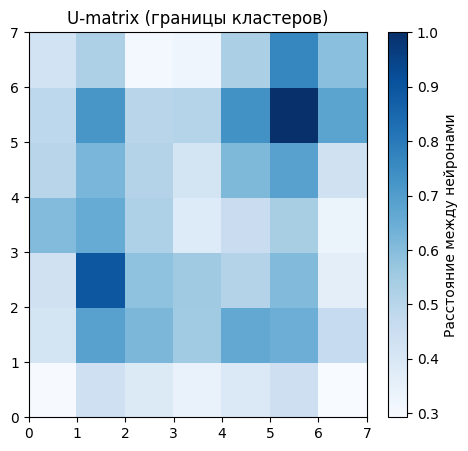

In [40]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
umatrix = som.distance_map()
plt.pcolor(umatrix.T, cmap='Blues')
plt.colorbar(label='Расстояние между нейронами')
plt.title('U-matrix (границы кластеров)')

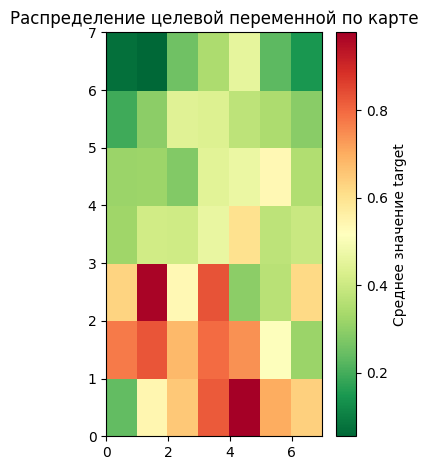

In [39]:
plt.subplot(1, 2, 2)
target_by_neuron = np.zeros(som_shape)
count_by_neuron = np.zeros(som_shape)

for sample, target_val in zip(X_scaled, y['ratio_underage_partic']):
    #print(sample, target_val)
    winner = som.winner(sample)
    target_by_neuron[winner] += target_val
    count_by_neuron[winner] += 1

mask = count_by_neuron > 0
target_by_neuron[mask] /= count_by_neuron[mask]

plt.pcolor(target_by_neuron.T, cmap='RdYlGn_r')
plt.colorbar(label='Среднее значение target')
plt.title('Распределение целевой переменной по карте')

plt.tight_layout()
plt.show()

In [28]:
winner_coords = []
for sample in X_scaled:
    winner = som.winner(sample)  # возвращает (x, y) координаты
    winner_coords.append(winner)

In [29]:
winner_ids = [x * som_shape[1] + y for x, y in winner_coords]

In [64]:
som_predictors = pd.get_dummies(winner_ids, drop_first=True, dtype=int, prefix='neuron')
som_predictors

,neuron_1,neuron_2,neuron_3,neuron_4,neuron_5,neuron_6,neuron_7,neuron_8,neuron_9,neuron_10,...,neuron_39,neuron_40,neuron_41,neuron_42,neuron_43,neuron_44,neuron_45,neuron_46,neuron_47,neuron_48
0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
80,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
81,0,0,0,0,0,0,0,1,0,0,...,0,0,0,0,0,0,0,0,0,0
82,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
83,0,0,0,0,0,0,0,0,1,0,...,0,0,0,0,0,0,0,0,0,0


In [77]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [78]:
X_train_scaled = pd.DataFrame(scaler.fit_transform(X_train), columns=X_train.columns, index=X_train.index)
X_test_scaled = pd.DataFrame(scaler.fit_transform(X_test), columns=X_test.columns, index=X_test.index)

In [79]:
X_train_scaled = X_train_scaled.merge(som_predictors, left_index=True, right_index=True)
X_test_scaled = X_test_scaled.merge(som_predictors, left_index=True, right_index=True)

In [81]:
X_train_scaled.to_csv('csv/predictors_withsom_scaled_train.csv', index=False)
X_test_scaled.to_csv('csv/predictors_withsom_scaled_test.csv', index=False)

In [87]:
X_train = X_train.merge(pd.Series(winner_ids, name='som_neuron_id'), left_index=True, right_index=True)
X_test = X_test.merge(pd.Series(winner_ids, name='som_neuron_id'), left_index=True, right_index=True)

In [88]:
X_train_scaled = pd.DataFrame(scaler.fit_transform(X_train), columns=X_train.columns, index=X_train.index)
X_test_scaled = pd.DataFrame(scaler.fit_transform(X_test), columns=X_test.columns, index=X_test.index)

In [89]:
X_train_scaled.to_csv('csv/predictors_with_onesom_scaled_train.csv', index=False)
X_test_scaled.to_csv('csv/predictors_with_onesom_scaled_test.csv', index=False)